In [3]:
implicit_multiplication(True)  

In [4]:
def get_canonical(C):
    kC = C.function_field()
    K = kC.gen().differential().divisor()  # canonical divisor
    return K
    
def get_degree_canonical(C):
    P1.<x,y> = ProjectiveSpace(QQ, 1)
    #P2.<x,y,z> = ProjectiveSpace(QQ, 2)
    K = get_canonical(C)
    basis = (-K).basis_function_space()
    Basis = [C.pull_from_function_field(f) for f in basis]
    phi = C.hom(Basis, P1)
    D = phi.image()  # conic
    return -1 * D.degree()

def genus_degree_formula(X):
    return _genus_degree_formula( 
        X.defining_polynomial().degree(),
        X.singular_points()
    )
    
def _genus_degree_formula(d,rs):
    return (1/2)*(d-1)*(d-2) - 1/2*sum( [r * r-1 for r in rs])

def irr(C):
    return( C.arithmetic_genus() - C.genus() )

def proj_closure(Y):
    return Curve( Y.defining_polynomial().homogenize() )

def summarize(Y, xbounds = (x,-5, 5), ybounds = (y,-5, 5)):
    f = Y.defining_polynomial()
    d = f.degree()
    #I = Ideal([F])
    #g = I.genus()
    X = proj_closure(Y)
    X_sing = X.singular_points()    
    mults = [ X.multiplicity(p) for p in X_sing ]
    pa = X.arithmetic_genus()
    pg = X.genus()

    if X.is_smooth():
        assert pa == pg
    if X.is_irreducible() and all([ X.is_ordinary_singularity(p) for p in X_sing ]):
        assert pa == _genus_degree_formula(d, []), f"p_a = {pa}, formula yields {_genus_degree_formula(d, []) }"
        assert pg == _genus_degree_formula(d, mults), f"p_g = {pg}, formula yields {_genus_degree_formula(d, mults) } using {mults}"

    K = get_canonical(X)
    dK = K.degree()
    assert dK == 2*pg - 2
    
    print(f"""
Polynomial: {Y.defining_polynomial()}
Homogenization: {Y.defining_polynomial().homogenize()}
Degree: {Y.defining_polynomial().degree()}
Smoothness: Affine: {Y.is_smooth()}, Projective: {X.is_smooth()}
Irreducible? {X.is_irreducible()}
Singular points: {X_sing}
Multiplicities: {mults}
Geometric genus: {pg}
Arithmetic genus: {pa}
Irregularity: {irr(X)}
K_X: {K}
deg(K_X): {dK}
    """)
    if pg == 1:
        E = Jacobian(f)
        print(f"Equivalent to: {E}")
        jE = E.j_invariant()
        print(f"j={jE}")
        from sage.schemes.toric.weierstrass import j_invariant  
        assert j_invariant(f) == jE
        bad_primes = reduce( 
            lambda a,b: a.union(b), [set( prime_divisors(n) ) 
            for n in E.defining_polynomial().coefficients() ] 
        )
        S = (p for p in Primes() 
             if E.has_good_reduction(p) 
             and p not in bad_primes
            )
        p = next(S)
        Ep = E.change_ring(GF(p))
        R.<t> = PowerSeriesRing(Integers())
        Zt = Ep.zeta_series(3, t)
        print(f"Zeta series for E over F_{{{p}}}: {Zt}")
    print(f"Point counts over F_{{3^k}}: {get_poly(X, p=3, n=5)}")
    return X.plot(xbounds, ybounds, gridlines=True, figsize=[10,10])

def get_poly(C, p=2, n=7):
    var('t')
    
    return sum([ 
        len(X.change_ring( GF(p^k) ).rational_points())*t^k 
        for k in [1..n] 
    ])

In [5]:
R.<x,y,z> = GF(2)[]
f = x^3*y + y^3*z + x*z^3
C = Curve(f); pts = C.rational_points()
D = C.divisor([ (4, pts[0]), (4, pts[2]) ])
D

4*(x, y) + 4*(y, z)

In [6]:
P.<x,y> = PolynomialRing(QQ)  
X = Curve(y^2 - 2*x^5 - 2*x^3 + 3*x - 2)
summarize(X)


Polynomial: -2*x^5 - 2*x^3 + y^2 + 3*x - 2
Homogenization: -2*x^5 - 2*x^3*h^2 + y^2*h^3 + 3*x*h^4 - 2*h^5
Degree: 5
Smoothness: Affine: True, Projective: False
Irreducible? True
Singular points: [(0 : 1 : 0)]
Multiplicities: [3]
Geometric genus: 2
Arithmetic genus: 6
Irregularity: 4
K_X: Place (1/y, 1/y*h, 1/y^2*h^2, 1/y^2*h^3 - 1/2*h, 1/y*h^4 - 3/2/y*h^3 - 1/2*y*h^2)
 - 2*Place (1/y, 1/y^2*h, 1/y^2*h^2 - 1/2, 1/y^2*h^3 - 1/2*h - 3/4, 1/y*h^4 - 3/2/y*h^3 - 1/2*y*h^2 + 1/y*h)
 + Place (y, y*h, y*h^2, y*h^3, y*h^4)
deg(K_X): 2
    
Point counts over F_{3^k}: 243*t^5 + 117*t^4 + 27*t^3 + 9*t^2 + 3*t


TypeError: Optional parameter must contain variable of ideal generator.

In [8]:
P.<x,y> = PolynomialRing(QQ)  

points = [ (1,2), (1,-2), (-2, 1), (-2, -1)]
var('a,b,c,d,e,f,g')

#f = a*y^3 - b*x^5 - c*x^2 - d*x - e

f = y^2 - a*x^4 - b*x^2 + c*x - 1

eqns = [
    f(x=p[0], y=p[1]) == 0 for p in points
]
solns = solve(eqns, a,b,c,d,e)
print(solns)

[
[a == -1/2*r3 - 1, b == 3/2*r3 + 4, c == r3, d == r2, e == r1]
]


[a == -1/2*r3 - 1, b == 3/2*r3 + 4, c == r3, d == r2, e == r1]
2*x^4 - 7*x^2 + y^2 + 2*x - 1

Polynomial: 2*x^4 - 7*x^2 + y^2 + 2*x - 1
Homogenization: 2*x^4 - 7*x^2*h^2 + y^2*h^2 + 2*x*h^3 - h^4
Degree: 4
Smoothness: Affine: True, Projective: False
Irreducible? True
Singular points: [(0 : 1 : 0)]
Multiplicities: [2]
Geometric genus: 1
Arithmetic genus: 3
Irregularity: 2
K_X: -2*Place (1/y, 1/y*h - 1, 1/y^2*h^2 - 1, 1/y*h^3 - 2/y*h^2 - y*h + 7)
 - 2*Place (1/y, 1/y*h + 1, 1/y^2*h^2 - 1, 1/y*h^3 - 2/y*h^2 - y*h - 7)
 + Place (y, y*h, y*h^2, y*h^3)
deg(K_X): 0
    
Equivalent to: Elliptic Curve defined by y^2 = x^3 - 25/3*x + 1478/27 over Rational Field
j=-15625/307
Zeta series for E over F_{7}: 1 + 11*t + 88*t^2 + 627*t^3 + O(t^4)
Point counts over F_{3^k}: 244*t^5 + 94*t^4 + 16*t^3 + 10*t^2 + 4*t


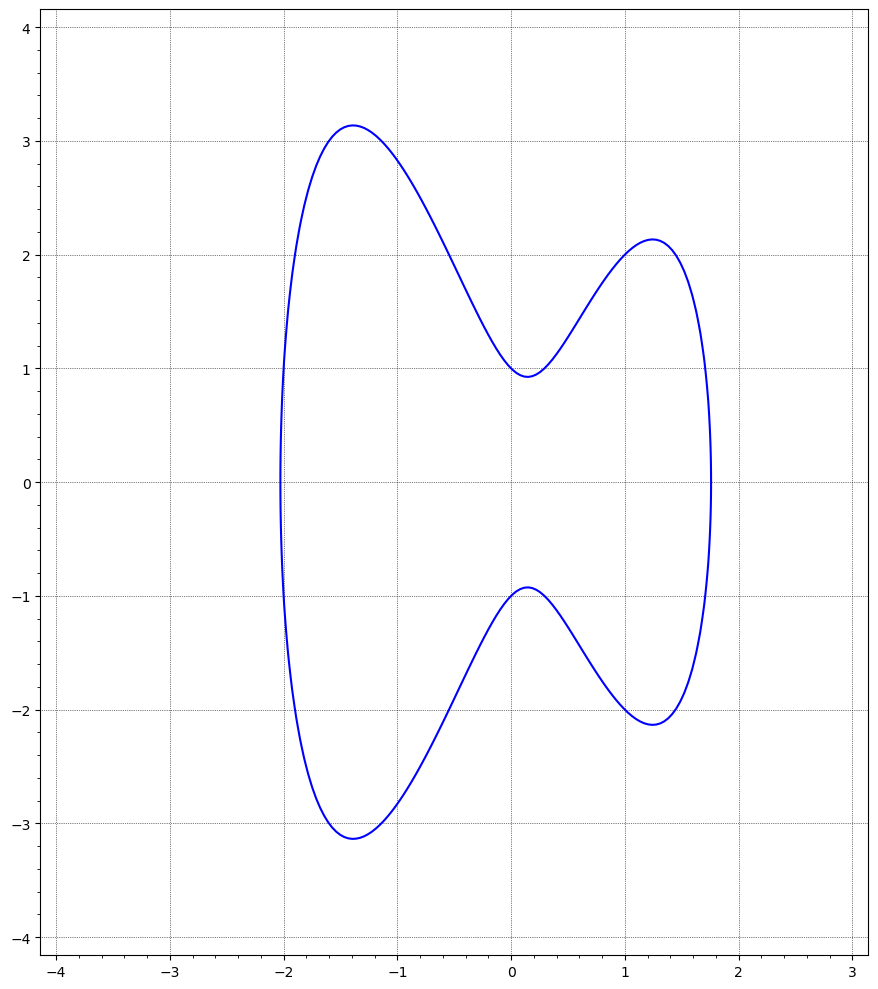

In [11]:
assert len(solns) > 0, "No solutions."
soln = solns[0]
print(soln)
F = P( (f.subs(soln)(r3 = 2, r2 = 1, r1 = 1)).polynomial(QQ) )
print(F)
X = Curve(F)
E = Jacobian(X)
show( summarize(X, xbounds=(x,-4,3), ybounds=(y,-4,4))    )

In [23]:
# 2*x^4 - 7*x^2 + y^2 + 2*x - 1
g = y^2 - a*x^4 - b*x^2 + 2*x - 1
points = [ (1,2), (1,-2), (-2, 1), (-2, -1)]

solve( [g(x=p[0], y=p[1]) == 0 for p in points], a,b)

[[a == -2, b == 7]]

In [24]:
 [g(x=p[0], y=p[1]) == 0 for p in points]

[-a - b + 5 == 0, -a - b + 5 == 0, -16*a - 4*b - 4 == 0, -16*a - 4*b - 4 == 0]

In [50]:
M = matrix(ZZ, 2, 2, [ [-1,-1], [-16,-4] ])
b = vector( [-5, 4] )

print(M,b)
a1,b1 = M.solve_right(b)
print(a1,b1)
g(a=a1,b=b1)

[ -1  -1]
[-16  -4] (-5, 4)
-2 7


2*x^4 - 7*x^2 + y^2 + 2*x - 1

2*x^4 - x^2 + y^2 + 2*x - 1

Polynomial: 2*x^4 - x^2 + y^2 + 2*x - 1
Homogenization: 2*x^4 - x^2*h^2 + y^2*h^2 + 2*x*h^3 - h^4
Degree: 4
Smoothness: Affine: True, Projective: False
Irreducible? True
Singular points: [(0 : 1 : 0)]
Multiplicities: [2]
Geometric genus: 1
Arithmetic genus: 3
Irregularity: 2
K_X: -2*Place (1/y, 1/y*h - 1, 1/y^2*h^2 - 1, 1/y*h^3 - 2/y*h^2 - y*h + 1)
 - 2*Place (1/y, 1/y*h + 1, 1/y^2*h^2 - 1, 1/y*h^3 - 2/y*h^2 - y*h - 1)
 + Place (y, y*h, y*h^2, y*h^3)
deg(K_X): 0
    
Equivalent to: Elliptic Curve defined by y^2 = x^3 + 23/3*x - 70/27 over Rational Field
j=48668/31
Zeta series for E over F_{11}: 1 + 10*t + 120*t^2 + 1330*t^3 + O(t^4)
Point counts over F_{3^k}: 244*t^5 + 94*t^4 + 16*t^3 + 10*t^2 + 4*t


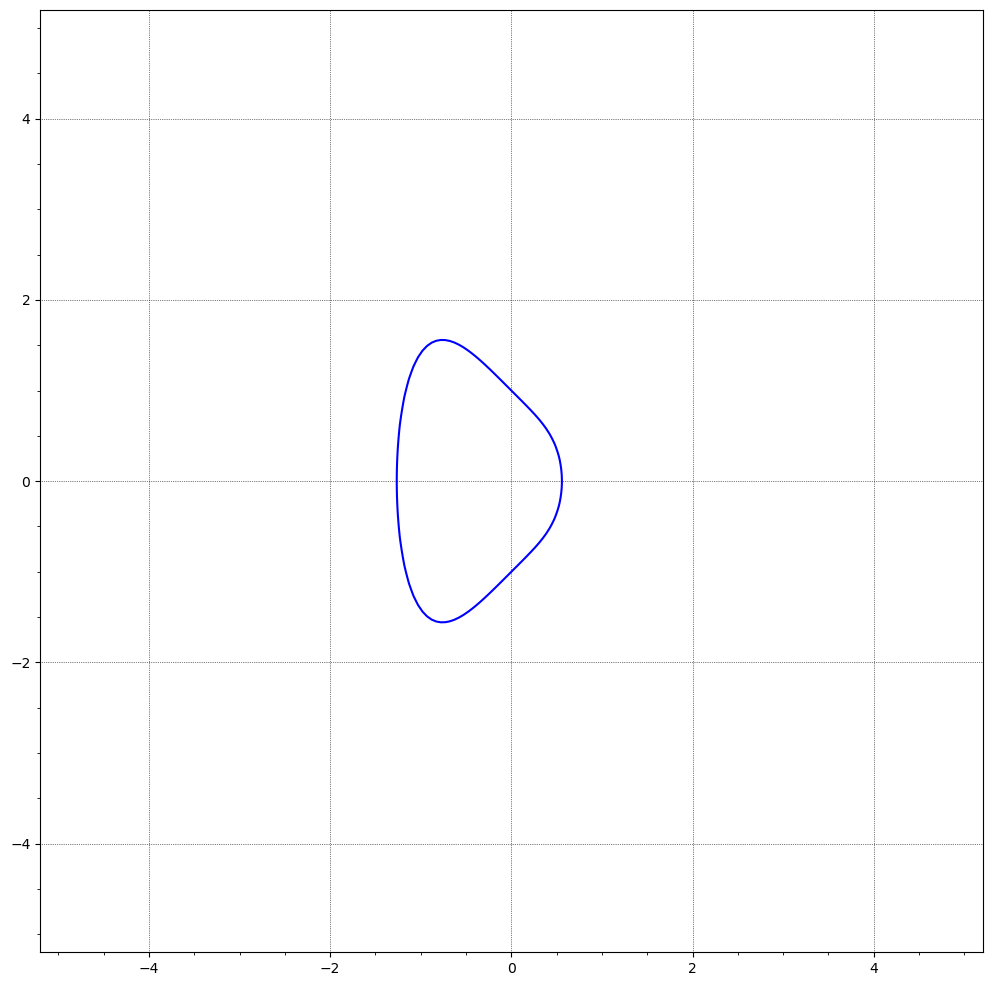

In [51]:
P.<x,y> = PolynomialRing(QQ)  

h = y^2 - a1*x^4 - 1*x^2 + 2*x - 1
print(h)

X = Curve(h)
summarize(X)

In [65]:
A.<t> = PolynomialRing(ZZ, 1)
Z = A(0)

for k in [1,..5]:
    F = GF(3^k)
    Px.<x,y> = PolynomialRing(F, 2)
    h = 2*x^4 - x^2 + y^2 + 2*x - 1
    solns = [P for P in cartesian_product([F, F]) if h(x = P[0],y = P[1]) == 0]
    Z = Z + len(solns) * t^k

print(Z)

244*t^5 + 94*t^4 + 16*t^3 + 10*t^2 + 4*t


In [11]:
var('l, a')
a = 2 + i*l
( a^2 + (a.conjugate())^2 ).simplify_full()

-2*l^2 + 8

In [13]:
solve( [  a^2 + (a.conjugate())^2 == 1], l )

[l == -1/2*sqrt(7)*sqrt(2), l == 1/2*sqrt(7)*sqrt(2)]

In [17]:
a.norm()

15/2

In [72]:
NS[1]
n_elts(1).simplify_full()
#NS[2]
#n_elts(2).simplify_full()
a.norm()

x^2 + y^2

Affine Plane Curve over Rational Field defined by 2*x^4 - x^2 + y^2 + 2*x - 1

Affine Plane Curve over Finite Field of size 5 defined by 2*x^4 - x^2 + y^2 + 2*x - 1

[4, 30, 148, 638]

In [156]:
R.<t> = PowerSeriesRing(ZZ)

var('a_x, a_y')
assume(a_x, "real")
assume(a_y, "real")
a = a_x + i*a_y

q = 17

def n_elts(a, m):
    return ( (q^m+1) - (a^m + a.conjugate()^m) ).simplify_full()


P.<x,y> = PolynomialRing(ZZ, 2)

X = Curve( 2*x^4 - x^2 + y^2 + 2*x - 1 )
assert X.genus() == 1 
assert X.is_smooth()

Xq = X.change_ring ( GF(q) )
assert Xq.genus() == 1 
assert Xq.is_smooth()


PXq = Xq.projective_closure()
assert PXq.genus() == 1 
assert PXq.is_smooth()


point_counts = PXq.count_points(4)
display(f"{Xq.count_points(4)} -> {point_counts}")

solns = solve( [ 
    point_counts[0] == n_elts(a, 1), 
    point_counts[1] == n_elts(a, 2) 
], a_x,a_y )

display( solns ) 
alpha = a.subs( solns[0] )
print(f"alpha = {alpha}. Norm = {alpha.norm()}" )
assert alpha.norm() == sqrt(q)

AssertionError: 

In [141]:
PX5 = X5.projective_closure()
PX5.count_points

Projective Plane Curve over Finite Field of size 5 defined by 2*x0^4 + x0^3*x1 + 2*x0^2*x1^2 + x1^4 - 2*x0^2*x2^2

In [130]:
[ n_elts(alpha, m) for m in [1,2,3,4] ]

[4, 30, 142, 642]

In [149]:
PX5.genus()

1

In [81]:
Zt = X.change_ring(GF(3)).zeta_series(4, t)

Zpt = t * log(Zt).derivative(t)
Zpt

4*t + 10*t^2 + 16*t^3 + 94*t^4 + O(t^5)

[4, 30, 148, 638]

In [101]:
q = 5
qms = [q^m + 1 for m in [1..5]]
qms

[6, 26, 126, 626, 3126]

In [94]:
#P.<x,y> = PolynomialRing(ZZ, 2)  
f = X.defining_polynomial() # your genus-1 polynomial  
from sage.schemes.elliptic_curves.jacobian import Jacobian_of_equation  
E = Jacobian_of_equation(f)
E

Elliptic Curve defined by y^2 = x^3 + 23/3*x - 70/27 over Rational Field

In [98]:
Fp = GF(5)
E_fp = E.change_ring(Fp)


In [97]:
(i*y)^2 + (-i*y)^2

-2*y^2